In [4]:
import itertools
import random

In [5]:
states_needed = set(["mt", "wa", "or", "id", "nv", "ut", "ca", "az"])

stations = {}
stations["kone"] = set(["id", "nv", "ut"])
stations["ktwo"] = set(["wa", "id", "mt"])
stations["kthree"] = set(["or", "nv", "ca"])
stations["kfour"] = set(["nv", "ut"])
stations["kfive"] = set(["ca", "az"])

final_stations = set()

while states_needed:
  best_station = None
  states_covered = set()
  for station, states_for_station in stations.items():
    covered = states_needed & states_for_station
    if len(covered) > len(states_covered):
      best_station = station
      states_covered = covered

  states_needed -= states_covered
  final_stations.add(best_station)

print(final_stations)

{'kthree', 'kone', 'ktwo', 'kfive'}


№ 1<br/>
**(2 балла)**<br/>
Предположим, что вы собираетесь в турпоход. У вас есть рюкзак, емкость которого
составляет 6 фунтов, и список предметов, которые вы можете положить с собой в рюкзак.
У каждого предмета есть вес и ценность. Чем выше ценность, тем важнее для вас предмет.
Нарисуйте и вручную заполните таблицу, которая даст оптимальный набор предметов для
похода и общую ценность получившегося рюкзака. Ориентируйтесь на алгоритм
динамического программирования, описанный в лекции.
Список предметов возьмите согласно вашему варианту.


Вариант 4.
1. вода, 2 фунта, 6;
2. книга, 1 фунт, 3;
3. еда, 4 фунта, 9;
4. куртка, 1 фунт, 5;
5. камера, 3 фунта, 6 

In [3]:
# ======= ПАРАМЕТРЫ =======

items = [
    {"name": "вода",    "weight": 2,    "value": 6},
    {"name": "книга",   "weight": 1,    "value": 3},
    {"name": "еда",     "weight": 4,    "value": 9},
    {"name": "куртка",  "weight": 1,    "value": 5},
    {"name": "камера",  "weight": 3,    "value": 6},
]

capacity = 6

# ======= ТАБЛИЦА =======

n = len(items)

dp = [[0] * (capacity + 1) for _ in range(n+1)]

for i in range(1, n + 1):
    weight = items[i-1]["weight"]
    value = items[i-1]["value"]
    for w in range(capacity + 1):
        if weight > w:
            dp[i][w] = dp[i-1][w]
        else:
            dp[i][w] = max(dp[i - 1][w], dp[i - 1][w - weight] + value)

print(f"{'i\\w':<4}", end="")
for w in range(capacity + 1):
    print(f"{w:>4}", end="")
print("\n" + "-"*35)

for i in range(n + 1):
    if i == 0:
        print(f"{'0':<4}", end="")
    else:
        print(f"{i:<4}", end="")
    
    for w in range(capacity + 1):
        print(f"{dp[i][w]:>4}", end="")
    print()

i\w    0   1   2   3   4   5   6
-----------------------------------
0      0   0   0   0   0   0   0
1      0   0   6   6   6   6   6
2      0   3   6   9   9   9   9
3      0   3   6   9   9  12  15
4      0   5   8  11  14  14  17
5      0   5   8  11  14  14  17


№ 2<br/>
**(3 балла)**<br/>
Напишите программу, которая моделирует задачу о рюкзаке. Пользователь вводит объем
рюкзака и список предметов с указанием их веса и ценности. Вам необходимо подобрать
набор предметов максимальной ценности, которые поместятся в рюкзаке. Реализуйте три
варианта решения этой задачи:

1. Полный перебор
2. Жадный алгоритм
3. Динамическое программирование

Укажите вычислительная сложность (в O-нотации) для каждого алгоритма. Постройте
графики возрастания времени выполнения алгоритмов при увеличении входных данных.

Приведите примеры входных данных, когда жадный алгоритм дает оптимальное решение
и когда дает неоптимальное решение.


In [4]:
# ======= АЛГОРИТМЫ =======

def knapsack_brute_force(capacity, items):
    """
    Полный перебор. Перебирает все возможные комбинации предметов
    """
    n = len(items)
    max_value = 0
    best_combination = []

    for r in range(1, n + 1):
        for combination in itertools.combinations(items, r):
            current_weight = sum(item['weight'] for item in combination)
            current_value = sum(item['value'] for item in combination)

            if current_weight <= capacity:
                if current_value > max_value:
                    max_value = current_value
                    best_combination = combination
    
    return max_value, [item['name'] for item in best_combination]
    pass

def knapsack_greedy(capacity, items):
    """
    Жадный алгоритм. Выбирает предметы с максимальной удельной ценностью (оптимальный вариант)
    """
    sorted_items = sorted(items, key=lambda x: x['value'] / x['weight'], reverse=True)

    total_value = 0
    current_weight = 0
    selected_items = []

    for item in sorted_items:
        if current_weight + item['weight'] <= capacity:
            current_weight += item['weight']
            total_value += item['value']
            selected_items.append(item['name'])
    return total_value, selected_items
    pass

def knapsack_dp(capacity, items):
    """
    Динамическое программирование – метод решения сложных задач, 
    разбиваемых на подзадачи, которые решаются в первую очередь.
    """
    n = len(items)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        item = items[i-1]
        w, v = item['weight'], item['value']
        for j in range(capacity + 1):
            if w <= j:
                dp[i][j] = max(dp[i-1][j], dp[i-1][j-w] + v)
            else:
                dp[i][j] = dp[i-1][j]
                
    # Восстановление ответа (какие предметы взяли)
    res = dp[n][capacity]
    w_curr = capacity
    selected_items = []
    for i in range(n, 0, -1):
        if res <= 0: break
        if res == dp[i-1][w_curr]:
            continue
        else:
            item = items[i-1]
            selected_items.append(item['name'])
            res -= item['value']
            w_curr -= item['weight']
            
    return dp[n][capacity], selected_items

    return
    pass

# ======= ПАРАМЕТРЫ =======

items = [
    {"name": "вода",    "weight": 2,    "value": 6},
    {"name": "книга",   "weight": 1,    "value": 3},
    {"name": "еда",     "weight": 4,    "value": 9},
    {"name": "куртка",  "weight": 1,    "value": 5},
    {"name": "камера",  "weight": 3,    "value": 6},
]

capacity = 6

# ======= ВЫВОД =======

print("Brute Force:", knapsack_brute_force(capacity, items))
print("Greedy:", knapsack_greedy(capacity, items))
print("DP:", knapsack_dp(capacity, items))

Brute Force: (17, ['вода', 'куртка', 'камера'])
Greedy: (14, ['куртка', 'вода', 'книга'])
DP: (17, ['куртка', 'еда', 'книга'])


№ 3<br/>
**(2 балла)**<br/>
Нарисуйте и вручную заполните таблицу для вычисления самой длинной общей подстроки
между строками blue и clue. Ориентируйтесь на алгоритм динамического
программирования, описанный в лекции.


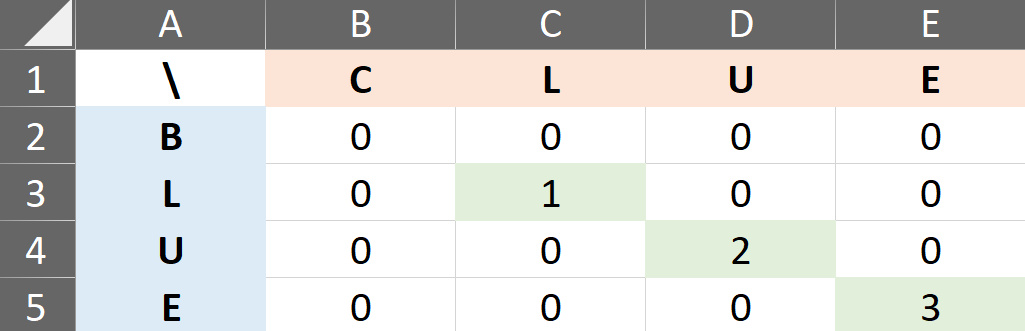
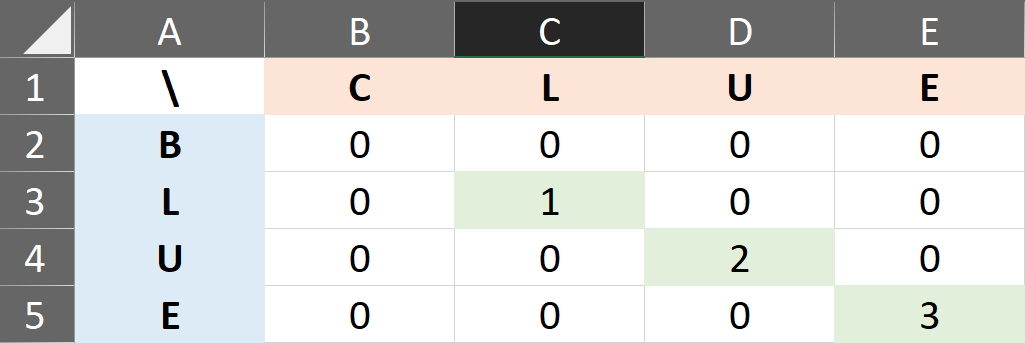
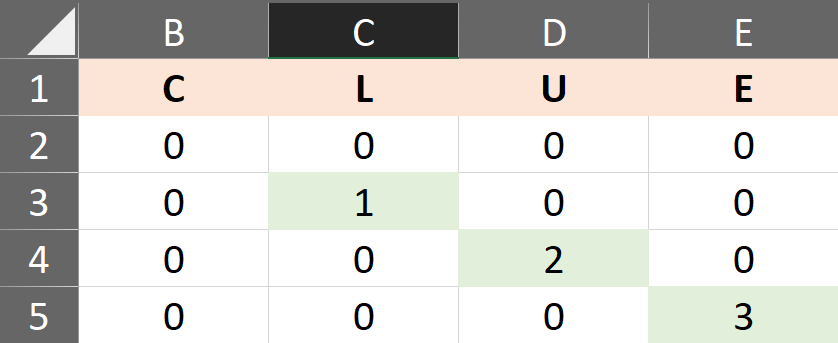

In [ ]:
"""
Если буквы совпадают, мы берем значение из ячейки сверху слева (по диагонали) и прибавляем 1
Формула: cell[i][j] = cell[i-1][j-1] + 1
"""

№ 4<br/>
**(3 балла)**<br/>
Напишите программу, реализующую алгоритм нахождения самой длинной общей
подстроки из лекции. Пользователь вводит слово с ошибкой и далее список похожих слов.
Ваша программа должна вывести самое похожее слово согласно данному алгоритму.

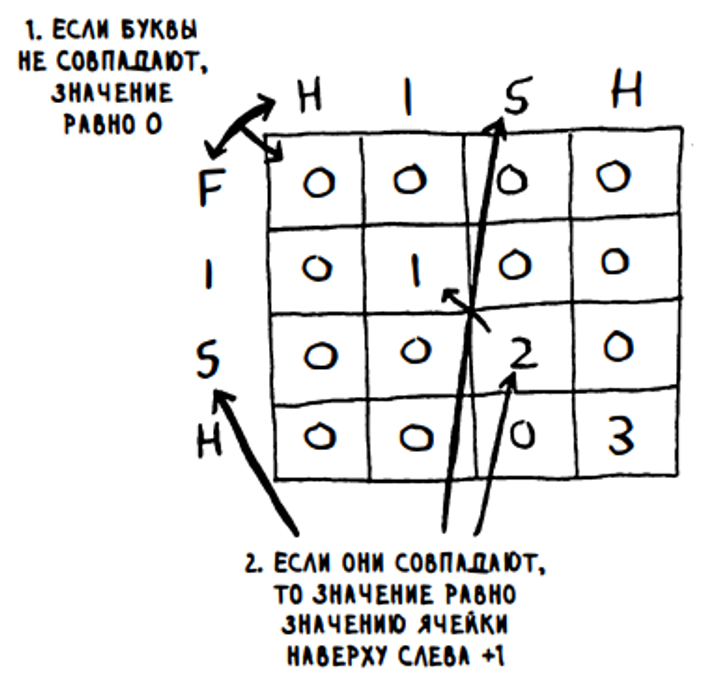

In [1]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======
def longest_common_substring_dp(word_one, word_two):
    """
    Днамическое программирвоание, таблица совпадения для
    нахождения длины самой длинной общей подстроки
    """
    # Создаем нулевую матрицу рахмеров ((len(word_one) + 1) x (len(word_two) + 1)) 
    n = len(word_one)
    m = len(word_two)
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    # Маскимально найденная длина
    max_len = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if word_one[i - 1] == word_two[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
                if dp[i][j] > max_len:
                    max_len = dp[i][j]
            else:
                dp[i][j] = 0

    return max_len
    pass

def find_most_similar(target, candidates):
    '''
    Обычный перебор списка слов с нахождением самой длинной
    общей подсроки с целевым словом
    '''
    best_candidate = ""
    max_len = -1

    for candidate in candidates:
        current_len = longest_common_substring_dp(target, candidate)

        if current_len > max_len:
            max_len = current_len
            best_candidate = candidate

    return best_candidate, max_len
    pass

# ======= ПАРАМЕТРЫ =======

target_word = "hish"

word_list = [
    "fish",
    "vista",
    "fort",
    "history"    
]

# ======= ВЫВОД =======

result_word, lcs_len = find_most_similar(target_word, word_list)

print(f"The word you are looking for: {target_word}")
print(f"Dictionary: {word_list}")
print('-'*50)
print(f"The most similar word: {result_word}")
print(f"The length of the general substring: {lcs_len}")


The word you are looking for: hish
Dictionary: ['fish', 'vista', 'fort', 'history']
--------------------------------------------------
The most similar word: fish
The length of the general substring: 3


№ 5<br/>
**(3 балла)**<br/>
Напишите программу, реализующую алгоритм нахождения самой длинной общей
подпоследовательности из лекции. Пользователь вводит слово с ошибкой и далее список
похожих слов. Ваша программа должна вывести самое похожее слово согласно данному
алгоритму.

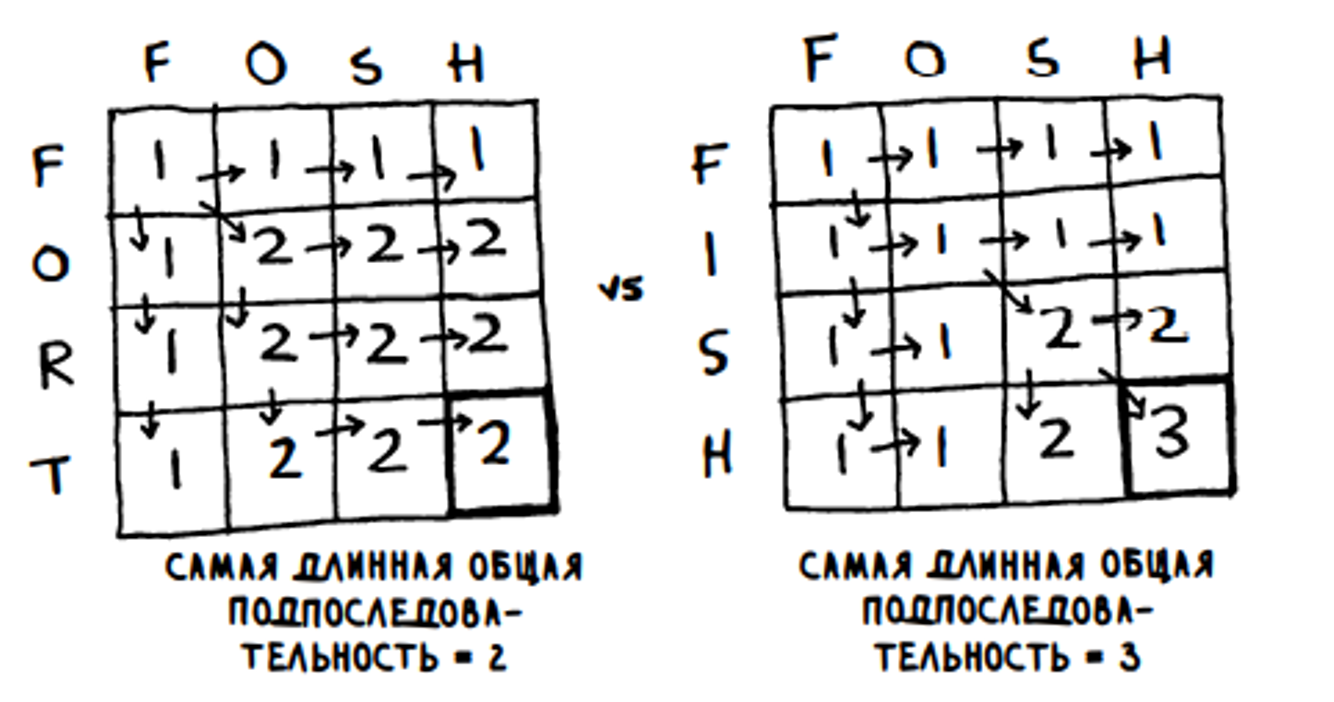
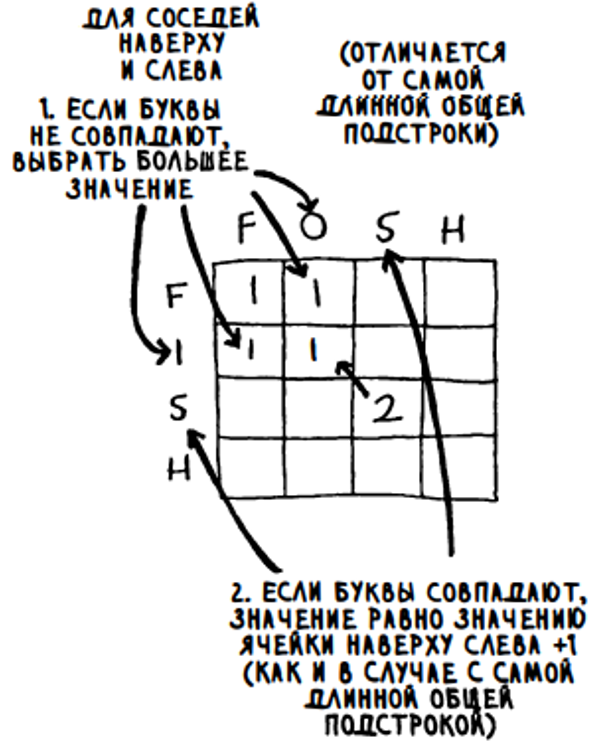

In [3]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

def longest_common_subsequence_dp(word_one, word_two):
    """
    """
    n = len(word_one)
    m = len(word_two)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            if word_one[i - 1] == word_two[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    
    return dp[n][m]
    pass

def find_most_similar(target, candidates):
    '''
    '''
    best_candidate = ""
    max_len = -1

    for candidate in candidates:
        current_len = longest_common_subsequence_dp(target, candidate)

        if current_len > max_len:
            max_len = current_len
            best_candidate = candidate

    return best_candidate, max_len
    pass

# ======= ПАРАМЕТРЫ =======

target_word = "fosh"

word_list = [
    "fort", 
    "fish"
]

# ======= ВЫВОД =======

result_word, lcs_len = find_most_similar(target_word, word_list)

print(f"The word you are looking for: {target_word}")
print(f"Dictionary: {word_list}")
print('-'*50)
print(f"The most similar word: {result_word}")
print(f"The length of the general substring: {lcs_len}")

The word you are looking for: fosh
Dictionary: ['fort', 'fish']
--------------------------------------------------
The most similar word: fish
The length of the general substring: 3


№ 6<br/>
**(4 балла)**<br/>
Имеется n предметов различных размеров (от 0.1 до 1.0). Есть неограниченное количество
одинаковых ящиков вместимостью 1.0. Необходимо разложить все n предметов в
минимальное количество ящиков.

Напишите программу, реализующую 4 жадных стратегии раскладки предметов по ящикам:
1. Первый подходящий ящик. Ящики просматриваются поочередно пока не найдется
ящик, в котором достаточно свободного места для упаковки очередного предмета.
Если такого ящика нет, то предмет кладется в новый ящик.
Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5, 0.3, 0.1], второй — [0.7, 0.2],
третий — [0.9], четвертый — [0.6, 0.4], пятый — [0.8], шестой — [0.5]. Т.е. ответом
будет 6 ящиков.
2. Наиболее подходящий ящик. Выбирается ящик, в котором останется как можно
меньше места после помещения туда очередного предмета. Укладка в новый ящик
применяется только в том случае, если очередной предмет не помещается ни в какой
из имеющихся ящиков.
Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5, 0.5], второй — [0.7, 0.3], третий
— [0.9, 0.1], четвертый — [0.6, 0.4], пятый — [0.8, 0.2]. Т.е. ответом будет 5 ящиков.
3. Следующий подходящий ящик. Мы продолжаем укладку каждого ящика до тех пор,
пока очередной предмет в него помещается. Если предмет не влезает в ящик, то мы
берем новый ящик, а к ранее уложенным ящикам уже не возвращаемся.
Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5], второй — [0.7, 0.3], третий —
[0.9], четвертый — [0.6], пятый — [0.8, 0.1], шестой — [0.4, 0.2], седьмой — [0.5].
Т.е. ответом будет 7 ящиков.
4. Наименее подходящий ящик. Выбирается ящик, в котором останется как можно
больше места после помещения туда очередного предмета. Укладка в новый ящик
применяется только в том случае, если очередной предмет не помещается ни в какой
из имеющихся ящиков.
Например, упаковка предметов размерами (0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5)
пройдет следующим образом: первый ящик — [0.5, 0.3], второй — [0.7], третий —
[0.9], четвертый — [0.6, 0.1], пятый — [0.8], шестой — [0.4, 0.2], седьмой — [0.5].
Т.е. ответом будет 7 ящиков.

Сгенерируйте случайные наборы предметов (размером от 0.1 до 0.9) в количестве 50, 100,
200 и 500. Осуществите на каждом из наборов проверку всех четырех стратегий и
посмотрите, какая из них приводит к меньшему числу ящиков.

В отчете приведите ваши результаты в виде таблицы.


In [ ]:
# ======= ВСПОМОГАТЛЬНЫЕ Ф-ЦИИ =======

def first_approach(items, capacity=1.0):
    """
    Первый подходящий ящик
    Ищем первый ящик, в который можно положить предмет
    Если не нашли, создаем новый ящик
    """
    boxes = []

    for item in items:
        placed = False
        for box in boxes:
            if sum(box) + item <= capacity:
                box.append(item)
                placed = True
                break
        # Создание нового ящика, если не удалось поместить предмет в существующие
        if not placed:
            boxes.append([item])

    return len(boxes)
    pass    

def second_approach(items, opacity=1.0):
    """
    Наиболее подходящий ящик
    Ищем ящик, в который предмет поместится с наименьшим остатком свободного места
    """
    boxes = []

    for item in items:
        best_box_index = -1
        # Больше максимальной емкости, чтобы гарантировать обновление
        min_space_left = opacity + 1

        # Перебор всех ящиков
        for i, box in enumerate(boxes):
            # Остаток места в ящике
            space_left = opacity - sum(box) 
            # Если предмет помещается и остаток меньше текущего минимума
            if space_left >= item and space_left - item < min_space_left: 
                # Текущий ящик, лучший среди других
                best_box_index = i
                # Обновляем минимальный остаток
                min_space_left = space_left - item

        # Если нашли подходящий ящик, то кладем туда предмет
        if best_box_index != -1:
            boxes[best_box_index].append(item)
        # Иначе создаем новый ящик
        else:
            boxes.append([item])
    
    return len(boxes)
    pass

def third_approach(items, opacity=1.0):
    """
    Следующий подходящий ящик
    Пытаемся положть в текущий ящик. Если не лезет - создаем новый ящик
    """
    # Начинаем с пустого ящика
    boxes = [0.0]

    for item in items:
        # Если предмет помещается в текущий ящик
        if boxes[-1] + item <= opacity:
            boxes[-1] += item
        else:
            # Создаем новый ящик
            boxes.append(item)

    return len(boxes)
    pass

def fourth_approach(items, opacity=1.0):
    """
    Наименее подходящий ящик
    Ищем ящики с максимальным остаточным местом после добавления предмета
    """
    # Принцип схож со вторым методом

    boxes = []

    for item in items:
        best_box_index = -1
        # Минимальный остаток места, чтобы гарантировать обновление
        max_space_left = -1

        # Перебор всех ящиков
        for i, box in enumerate(boxes):
            # Остаток места в ящике
            space_left = opacity - sum(box) 
            # Если предмет помещается и остаток больше текущего максимума
            if space_left >= item and space_left - item > max_space_left: 
                # Текущий ящик, лучший среди других
                best_box_index = i
                # Обновляем максимальный остаток
                max_space_left = space_left - item

        # Если нашли подходящий ящик, то кладем туда предмет
        if best_box_index != -1:
            boxes[best_box_index].append(item)
        # Иначе создаем новый ящик
        else:
            boxes.append([item])
    return len(boxes)
    pass

# ======= ПАРАМЕТРЫ =======

def generate_items(n):
    # Генерация предметов от 0.1 до 1.0
    return [round(random.uniform(0.1, 0.9), 1) for _ in range(n)]
    pass

n = [50, 100, 200, 500]

# ======= ВЫВОД =======
for count in n:
    print(f"Number of items: {count}")
    items = generate_items(count)
    
    res_first = first_approach(items)
    res_second = second_approach(items)
    res_third = third_approach(items)
    res_fourth = fourth_approach(items)

    print(f"Items: {items}")
    print(f"    First Approach: {res_first} boxes")
    print(f"    Second Approach: {res_second} boxes")
    print(f"    Third Approach: {res_third} boxes")
    print(f"    Fourth Approach: {res_fourth} boxes")
    print('-'*50)


Number of items: 50
Items: [0.8, 0.6, 0.2, 0.7, 0.3, 0.8, 0.3, 0.3, 0.8, 0.7, 0.9, 0.4, 0.7, 0.1, 0.5, 0.4, 0.2, 0.7, 0.5, 0.8, 0.8, 0.7, 0.6, 0.7, 0.8, 0.9, 0.7, 0.7, 0.3, 0.5, 0.7, 0.4, 0.2, 0.8, 0.7, 0.7, 0.7, 0.3, 0.6, 0.4, 0.8, 0.1, 0.8, 0.3, 0.3, 0.6, 0.4, 0.8, 0.5, 0.9]
    First Approach: 33 boxes
    Second Approach: 33 boxes
    Third Approach: 37 boxes
    Fourth Approach: 34 boxes
--------------------------------------------------
Number of items: 100
Items: [0.4, 0.1, 0.7, 0.7, 0.6, 0.8, 0.4, 0.7, 0.7, 0.6, 0.1, 0.8, 0.1, 0.6, 0.4, 0.1, 0.6, 0.9, 0.5, 0.5, 0.2, 0.4, 0.4, 0.1, 0.6, 0.5, 0.4, 0.6, 0.5, 0.3, 0.7, 0.7, 0.7, 0.7, 0.5, 0.5, 0.4, 0.4, 0.6, 0.3, 0.6, 0.4, 0.1, 0.3, 0.6, 0.3, 0.5, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.5, 0.7, 0.2, 0.9, 0.6, 0.9, 0.6, 0.5, 0.4, 0.2, 0.2, 0.3, 0.8, 0.5, 0.6, 0.3, 0.4, 0.6, 0.6, 0.7, 0.4, 0.6, 0.1, 0.6, 0.6, 0.7, 0.5, 0.6, 0.4, 0.8, 0.4, 0.2, 0.8, 0.2, 0.6, 0.5, 0.3, 0.5, 0.7, 0.5, 0.8, 0.3, 0.3, 0.8, 0.4, 0.5, 0.3]
    First Approach: 52 b

№ 7<br/>
**(4 балла)**<br/>
Есть купюры и монеты номиналами: 1, 3, 4, 10, 50, 100. В банкомате неограниченное
количество купюр и монет каждого номинала. Мы хотим снять со счета n рублей. Нужно
вывести на экран минимальный набор купюр и монет, который может выдать банкомат,
чтобы сумма получилась ровно n.
1. Напишите жадный алгоритм решения задачи. Подсказка: выбирайте купюры и
монеты по убыванию номинала.
2. Используйте динамическое программирование, чтобы рассчитать минимальное
количество требуемых купюр и монет.
3. Приведите пример входных данных, когда жадный алгоритм выдает не оптимальное
решение.

In [84]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

def greedy_change(n, coins):
    """
    Жадный алгоритм
    """

    sorted_coins = sorted(coins, reverse=True)
    result = []

    for coin in sorted_coins:
        while n >= coin:
            n -= coin
            result.append(coin)

    return sorted(result)
    pass

def dp_change(n, coins):
    """
    Динамическое программирование
    """
    # Максимальное огромное значение, чтобы гарантировать обновление
    min_coins = [n + 1] * (n + 1) 
    # 0 монет нужно для суммы 0
    min_coins[0] = 0 
    # Для восстановления решения, последняя добавленная монета
    coin_used = [0] * (n + 1) 

    for amount in range(1, n + 1):
        for coin in coins:
            if coin <= amount:
                # Если использование этой монеты дает меньшее количество монет
                if min_coins[amount - coin] + 1 < min_coins[amount]: 
                    min_coins[amount] = min_coins[amount - coin] + 1
                    coin_used[amount] = coin

    # Восстановление решения
    result = []
    amount = n
    while amount > 0:
        result.append(coin_used[amount])
        amount -= coin_used[amount]

    return result
    pass

# ======= ПАРАМЕТРЫ =======

coins = [1, 3, 4, 10, 50, 100]
amount = 96

# ======= ВЫВОД =======

print("Amount:", amount)
print("Greedy Change:", len(greedy_change(amount, coins)), greedy_change(amount, coins))
print("DP Change:", len(dp_change(amount, coins)), dp_change(amount, coins))

Amount: 96
Greedy Change: 8 [1, 1, 4, 10, 10, 10, 10, 50]
DP Change: 7 [3, 3, 10, 10, 10, 10, 50]


№ 8<br/>
**(4 балла)**<br/>
Напишите программу, моделирующую работу клиентов с банкоматом. В банкомате есть
купюры и монеты номиналами: 1, 3, 4, 10, 50, 100, но, в отличие от предыдущей задачи, их
количество конечно.
В начале работы программы вы задаете:
- количество клиентов
- для каждого клиента количество рублей, которые он хочет снять (считаем, что эта
сумма всегда корректна и имеется на счету клиента)
- изначальное количество купюр и монет в банкомате

Далее вы по очереди обрабатываете запросы клиентов. Для каждого клиента выведите на
экран минимальный набор купюр и монет для его суммы или сообщение о невозможности
предоставить данную суммы из-за нехватки купюр и монет. Если минимальный набор
найден успешно, то вычтите его из запасов банкомата и выведите на экран получившейся
остаток.

Проведите несколько запусков программы с разными начальными данными и различными
исходами работы с банкоматом.

In [86]:
# ======= ВСПОМОГАТЕЛЬНЫЕ Ф-ЦИИ =======

def terminal_solve(amount, limits):
    """
    Решение задачи о размене с ограничениями на количество банкнот
    """
    # Считывание и сортировка доступных номиналов по убыванию
    denominations = sorted(limits.keys(), reverse=True)

    result = {}
    remaining_amount = amount

    temp_limits = limits.copy()

    for coin in denominations:
        if remaining_amount == 0:
            break

        count_needed = remaining_amount // coin
        
        count_to_use = min(count_needed, temp_limits[coin])

        if count_to_use > 0:
            result[coin] = count_to_use
            remaining_amount -= coin * count_to_use
            temp_limits[coin] -= count_to_use

    if remaining_amount == 0:
        return result
    else:
        return None
    pass

def terminal_status(limits):
    """
    Вывод текущего состояния банкомата
    """
    print('-'*30)
    print("Current banknote limits:")
    for denom, count in sorted(limits.items(), reverse=True):
        print(f"  {denom}: {count}")
    print('-'*30)
    pass

# ======= ПАРАМЕТРЫ =======

banknote_limits = {
    100: 2,
    50: 5,
    10: 10,
    4: 20,
    3: 20,
    1: 50
}

num_clients = 10

# ======= ВЫВОД =======

terminal_status(banknote_limits)
for client_id in range(1, num_clients + 1):
    amount = random.randint(1, 300)
    print(f"Client {client_id} requests amount: {amount}")

    result = terminal_solve(amount, banknote_limits)

    if result is not None:
        print("  Dispensed banknotes:")
        for denom, count in sorted(result.items(), reverse=True):
            print(f"    {denom}: {count}")
            banknote_limits[denom] -= count
    else:
        print("  Cannot dispense the requested amount with available banknotes.")

    terminal_status(banknote_limits)

------------------------------
Current banknote limits:
  100: 2
  50: 5
  10: 10
  4: 20
  3: 20
  1: 50
------------------------------
Client 1 requests amount: 294
  Dispensed banknotes:
    100: 2
    50: 1
    10: 4
    4: 1
------------------------------
Current banknote limits:
  100: 0
  50: 4
  10: 6
  4: 19
  3: 20
  1: 50
------------------------------
Client 2 requests amount: 55
  Dispensed banknotes:
    50: 1
    4: 1
    1: 1
------------------------------
Current banknote limits:
  100: 0
  50: 3
  10: 6
  4: 18
  3: 20
  1: 49
------------------------------
Client 3 requests amount: 192
  Dispensed banknotes:
    50: 3
    10: 4
    1: 2
------------------------------
Current banknote limits:
  100: 0
  50: 0
  10: 2
  4: 18
  3: 20
  1: 47
------------------------------
Client 4 requests amount: 279
  Cannot dispense the requested amount with available banknotes.
------------------------------
Current banknote limits:
  100: 0
  50: 0
  10: 2
  4: 18
  3: 20
  1: 47
